<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/5G_Corona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive Mounting and Data Uploading

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 1: Upload file manually
from google.colab import files
import pandas as pd

uploaded = files.upload()  # This lets you pick file from your PC
file_path = list(uploaded.keys())[0]  # Automatically use uploaded filename

# Step 2: Read dataset
# Use pd.read_excel for .xlsx files
data = pd.read_excel(file_path)
print("5G_Datasets (first 5 rows):")
print(data.head())

Saving 5G_Datasets.xlsx to 5G_Datasets (2).xlsx
5G_Datasets (first 5 rows):
          ID  TimeStamp  Friends  Followers  Info_Type                 Time  \
0  679667751     413035        8         10          1  1900-01-04 18:43:55   
1  155445831     427290       10          9          1  1900-01-04 22:41:30   
2    3537700     518553       13         13          1  1900-01-06 00:02:33   
3   61899869     423686       10         14          1  1900-01-04 21:41:26   
4  701687124     418895        9          8          1  1900-01-04 20:21:35   

   Hour Peak_Off-Peak Time_Category  \
0    18          Peak       Evening   
1    22      Off-Peak         Night   
2     0      Off-Peak         Night   
3    21          Peak       Evening   
4    20          Peak       Evening   

                                       Tweet_Text  
0   Don't trust the media, COVID-19 is fake news!  
1   Don't trust the media, COVID-19 is fake news!  
2       COVID-19 is a hoax created by big pharma.  
3     

Required Installations

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn textblob nltk openpyxl

In [ ]:
!pip install textblob seaborn matplotlib pandas

Objective 1: Temporal Patterns (Peak vs Off-Peak and Time Categories)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             2086 non-null   int64 
 1   TimeStamp      2086 non-null   int64 
 2   Friends        2086 non-null   int64 
 3   Followers      2086 non-null   int64 
 4   Info_Type      2086 non-null   int64 
 5   Time           2086 non-null   object
 6   Hour           2086 non-null   int64 
 7   Peak_Off-Peak  2086 non-null   object
 8   Time_Category  2086 non-null   object
 9   Tweet_Text     2086 non-null   object
dtypes: int64(6), object(4)
memory usage: 163.1+ KB
Conspiracy vs Non-Conspiracy Counts:
 Info_Type
1    1082
0    1004
Name: count, dtype: int64


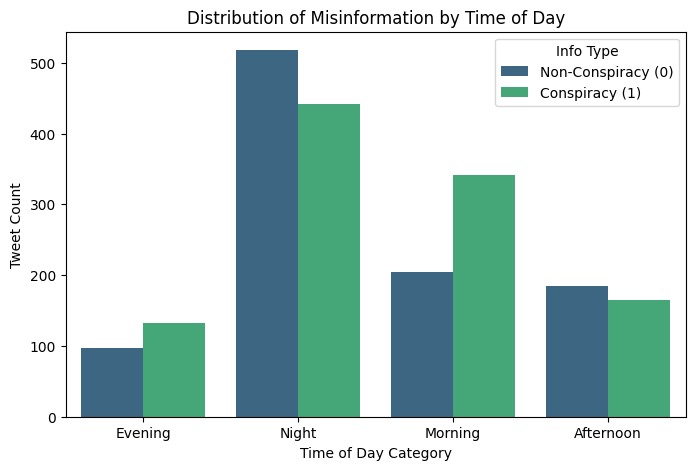


Peak vs Off-Peak (% distribution):
 Info_Type          0      1
Peak_Off-Peak              
Off-Peak       48.95  51.05
Peak           46.91  53.09


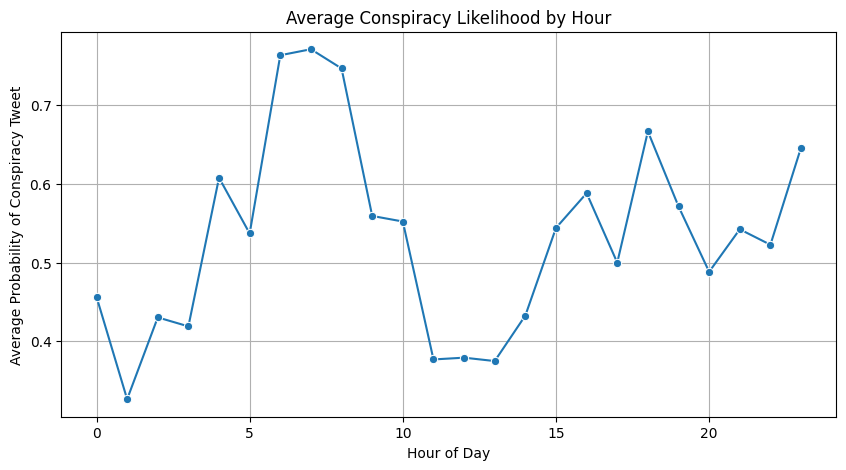

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from textblob import TextBlob
import nltk
nltk.download('punkt')

# Step 2: Read dataset (already uploaded via files.upload())
file_path = "5G_Datasets.xlsx"
data = pd.read_excel(file_path)

# Check dataset structure
data.info()

# Count of conspiracy (1) vs non-conspiracy (0)
misinfo_counts = data['Info_Type'].value_counts()
print("Conspiracy vs Non-Conspiracy Counts:\n", misinfo_counts)

# Frequency by time category
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Time_Category', hue='Info_Type', palette='viridis')
plt.title("Distribution of Misinformation by Time of Day")
plt.xlabel("Time of Day Category")
plt.ylabel("Tweet Count")
plt.legend(title="Info Type", labels=["Non-Conspiracy (0)", "Conspiracy (1)"])
plt.show()

# Peak vs Off-Peak comparison
peak_table = pd.crosstab(data['Peak_Off-Peak'], data['Info_Type'], normalize='index') * 100
print("\nPeak vs Off-Peak (% distribution):\n", peak_table.round(2))

# Time-based frequency
hourly = data.groupby('Hour')['Info_Type'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o')
plt.title("Average Conspiracy Likelihood by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Probability of Conspiracy Tweet")
plt.grid(True)
plt.show()

Objective 2: Sentiment Analysis (NLP on Tweet Texts)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             2086 non-null   int64 
 1   TimeStamp      2086 non-null   int64 
 2   Friends        2086 non-null   int64 
 3   Followers      2086 non-null   int64 
 4   Info_Type      2086 non-null   int64 
 5   Time           2086 non-null   object
 6   Hour           2086 non-null   int64 
 7   Peak_Off-Peak  2086 non-null   object
 8   Time_Category  2086 non-null   object
 9   Tweet_Text     2086 non-null   object
dtypes: int64(6), object(4)
memory usage: 163.1+ KB

📊 Average Sentiment by Tweet Type:

       Tweet_Type      mean       std  count
0      Conspiracy  0.017922  0.321165   1082
1  Non-Conspiracy  0.031873  0.316961   1004


/tmp/ipython-input-2864400306.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Tweet_Type', y='Sentiment', palette='coolwarm')


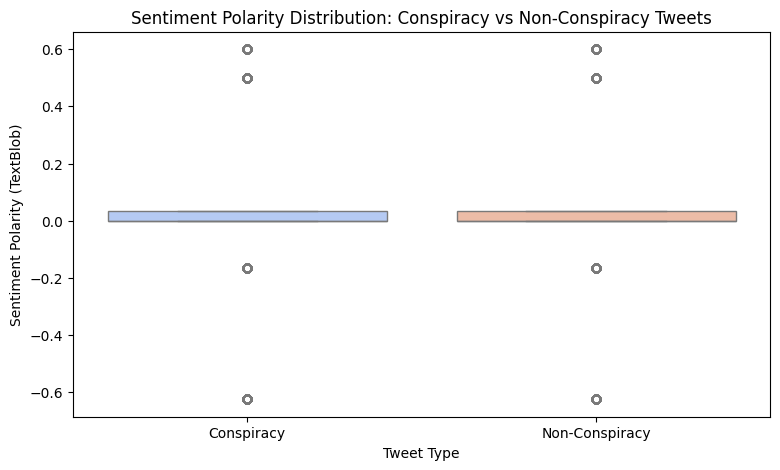

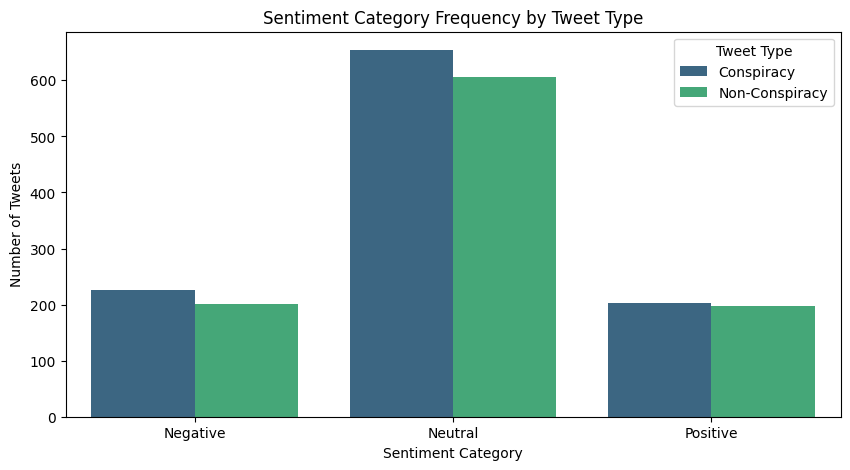

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from textblob import TextBlob
import nltk
nltk.download('punkt')

# Step 2: Read dataset (already uploaded via files.upload())
file_path = "5G_Datasets.xlsx"
data = pd.read_excel(file_path)

# Check dataset structure
data.info()

# Check for required text column
if 'Tweet_Text' in data.columns:

    # Compute sentiment polarity using TextBlob
    # Polarity ranges from -1 (very negative) to +1 (very positive)
    data['Sentiment'] = data['Tweet_Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

    # Categorize sentiment into Negative, Neutral, Positive
    data['Sentiment_Label'] = pd.cut(
        data['Sentiment'],
        bins=[-1, -0.05, 0.05, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )

    # Map Info_Type for clarity
    data['Tweet_Type'] = data['Info_Type'].map({0: 'Non-Conspiracy', 1: 'Conspiracy'})

    # ---------------------------------
    # Summary statistics of sentiment by tweet type
    sentiment_summary = data.groupby('Tweet_Type')['Sentiment'].agg(['mean', 'std', 'count']).reset_index()
    print("\n📊 Average Sentiment by Tweet Type:\n")
    print(sentiment_summary)

    # ---------------------------------
    # Visualization 1: Sentiment Distribution
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=data, x='Tweet_Type', y='Sentiment', palette='coolwarm')
    plt.title("Sentiment Polarity Distribution: Conspiracy vs Non-Conspiracy Tweets", fontsize=12)
    plt.xlabel("Tweet Type")
    plt.ylabel("Sentiment Polarity (TextBlob)")
    plt.show()

    # ---------------------------------
    # Visualization 2: Sentiment Category Counts
    plt.figure(figsize=(10, 5))
    sns.countplot(data=data, x='Sentiment_Label', hue='Tweet_Type', palette='viridis')
    plt.title("Sentiment Category Frequency by Tweet Type", fontsize=12)
    plt.xlabel("Sentiment Category")
    plt.ylabel("Number of Tweets")
    plt.legend(title='Tweet Type')
    plt.show()

else:
    print("⚠️ No 'Tweet_Text' column found. Please ensure the dataset includes text data for sentiment analysis.")

Objective 3: Modeling the Likelihood of Conspiracy Tweets

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2086 entries, 0 to 2085
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             2086 non-null   int64 
 1   TimeStamp      2086 non-null   int64 
 2   Friends        2086 non-null   int64 
 3   Followers      2086 non-null   int64 
 4   Info_Type      2086 non-null   int64 
 5   Time           2086 non-null   object
 6   Hour           2086 non-null   int64 
 7   Peak_Off-Peak  2086 non-null   object
 8   Time_Category  2086 non-null   object
 9   Tweet_Text     2086 non-null   object
dtypes: int64(6), object(4)
memory usage: 163.1+ KB

--- First 5 Rows ---
          ID  TimeStamp  Friends  Followers  Info_Type                 Time  \
0  679667751     413035        8         10          1  1900-01-04 18:43:55   
1  155445831     427290       10          9          1  1900-01-04 22:41:30   
2    3537700     518553       13         13 

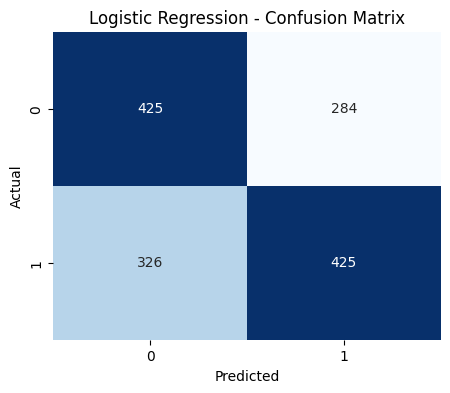


Random Forest Evaluation
Accuracy: 0.810958904109589
Precision: 0.8072445019404916
Recall: 0.8308921438082557
F1-Score: 0.8188976377952756
AUC: 0.9160705331302504
MAE: 0.18904109589041096
MSE: 0.18904109589041096
RMSE: 0.43478856458100523

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       709
           1       0.81      0.83      0.82       751

    accuracy                           0.81      1460
   macro avg       0.81      0.81      0.81      1460
weighted avg       0.81      0.81      0.81      1460



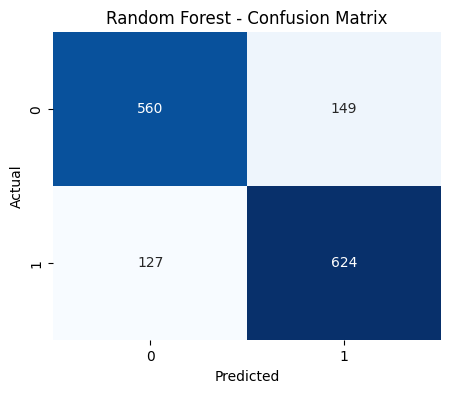

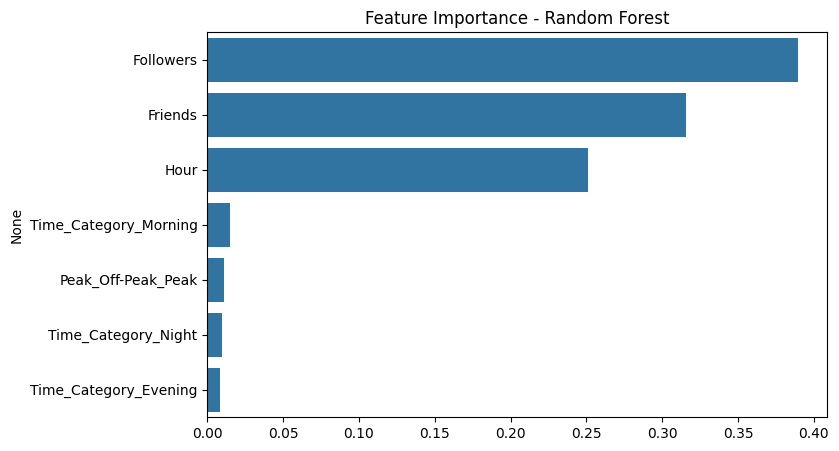


Naïve Bayes Evaluation
Accuracy: 0.5780821917808219
Precision: 0.597684515195369
Recall: 0.5499334221038615
F1-Score: 0.5728155339805825
AUC: 0.5964299598654544
MAE: 0.42191780821917807
MSE: 0.42191780821917807
RMSE: 0.6495520057848934

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.61      0.58       709
           1       0.60      0.55      0.57       751

    accuracy                           0.58      1460
   macro avg       0.58      0.58      0.58      1460
weighted avg       0.58      0.58      0.58      1460



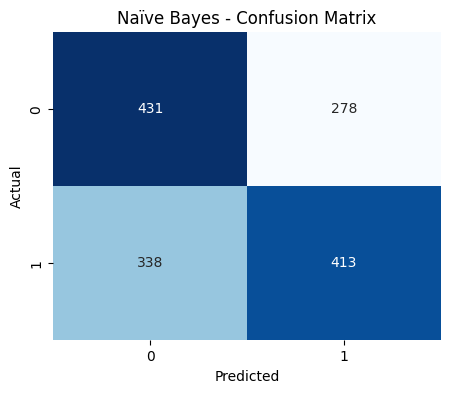

In [ ]:
# --- Import Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error
)
from textblob import TextBlob
import nltk
nltk.download('punkt')

# --- Step 1: Load Dataset ---
file_path = "5G_Datasets.xlsx"
data = pd.read_excel(file_path)

# Inspect dataset
print("\n--- Dataset Info ---")
data.info()
print("\n--- First 5 Rows ---")
print(data.head())

# --- Step 2: Encode Categorical Variables ---
df_encoded = pd.get_dummies(data, columns=['Peak_Off-Peak', 'Time_Category'], drop_first=True)

# Define features and target
X = df_encoded[['Friends', 'Followers', 'Hour'] + [col for col in df_encoded.columns if 'Peak_Off' in col or 'Time_Category_' in col]]
y = df_encoded['Info_Type']

# --- Step 3: Split Dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Step 4: Scale Numerical Features ---
scaler = StandardScaler()
X_train[['Friends', 'Followers', 'Hour']] = scaler.fit_transform(X_train[['Friends', 'Followers', 'Hour']])
X_test[['Friends', 'Followers', 'Hour']] = scaler.transform(X_test[['Friends', 'Followers', 'Hour']])

# --- Helper Function for Model Evaluation ---
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n{'='*40}\n{model_name} Evaluation\n{'='*40}")

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probabilities (for AUC)
    if hasattr(model, "predict_proba"):
        y_prob_train = model.predict_proba(X_train)[:, 1]
        auc = roc_auc_score(y_train, y_prob_train)
    else:
        auc = np.nan

    # Metrics
    mae = mean_absolute_error(y_train, y_pred_train)
    mse = mean_squared_error(y_train, y_pred_train)
    rmse = np.sqrt(mse)

    print("Accuracy:", accuracy_score(y_train, y_pred_train))
    print("Precision:", precision_score(y_train, y_pred_train))
    print("Recall:", recall_score(y_train, y_pred_train))
    print("F1-Score:", f1_score(y_train, y_pred_train))
    print("AUC:", auc)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)

    print("\nClassification Report:")
    print(classification_report(y_train, y_pred_train))

    # Confusion Matrix
    cm = confusion_matrix(y_train, y_pred_train)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
evaluate_model(log_model, X_train, X_test, y_train, y_test, "Logistic Regression")

# --- Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")

# --- Feature Importance for Random Forest ---
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feature_imp.values, y=feature_imp.index)
plt.title("Feature Importance - Random Forest")
plt.show()

# --- Naïve Bayes Classifier ---
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
evaluate_model(nb_model, X_train, X_test, y_train, y_test, "Naïve Bayes")


Objective 4: Trend and Probabilistic Analysis (Temporal Layer)

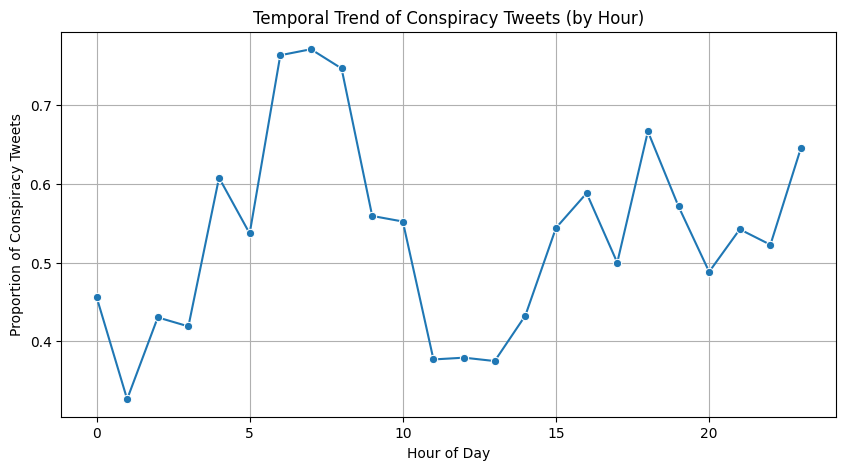

=== CHI-SQUARE TEST RESULTS ===
Contingency Table:
Info_Type        0    1
Time_Category          
Afternoon      185  165
Evening         97  133
Morning        204  342
Night          518  442

Expected Frequencies:
Info_Type               0           1
Time_Category                        
Afternoon      168.456376  181.543624
Evening        110.699904  119.300096
Morning        262.791946  283.208054
Night          462.051774  497.948226

Chi-Square Statistic (χ²): 44.8195
Degrees of Freedom: 3
P-Value: 0.000000

Residuals (Observed - Expected):
Info_Type              0          1
Time_Category                      
Afternoon      16.543624 -16.543624
Evening       -13.699904  13.699904
Morning       -58.791946  58.791946
Night          55.948226 -55.948226

Standardized Residuals:
Info_Type             0         1
Time_Category                    
Afternoon      1.274638 -1.227835
Evening       -1.302099  1.254288
Morning       -3.626702  3.493535
Night          2.602801 -2.507230

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# --- Temporal Trend Visualization ---
time_trend = data.groupby('Hour')['Info_Type'].agg(['count', 'mean']).reset_index()
time_trend.columns = ['Hour', 'Total_Tweets', 'Conspiracy_Rate']

plt.figure(figsize=(10,5))
sns.lineplot(x='Hour', y='Conspiracy_Rate', data=time_trend, marker='o')
plt.title("Temporal Trend of Conspiracy Tweets (by Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Proportion of Conspiracy Tweets")
plt.grid(True)
plt.show()

# --- Chi-Square Test for Time_Category vs Info_Type ---
contingency = pd.crosstab(data['Time_Category'], data['Info_Type'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("=== CHI-SQUARE TEST RESULTS ===")
print("Contingency Table:")
print(contingency)
print("\nExpected Frequencies:")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))
print(f"\nChi-Square Statistic (χ²): {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {p:.6f}")

# Calculate residuals
residuals = contingency - expected
standardized_residuals = residuals / np.sqrt(expected)

print("\nResiduals (Observed - Expected):")
print(residuals)
print("\nStandardized Residuals:")
print(standardized_residuals)

if p < 0.05:
    print("\nConclusion: Significant difference in misinformation frequency across time categories.")
else:
    print("\nConclusion: No significant difference across time categories.")

# --- G-Test (Likelihood Ratio Test) ---
# Formula: G = 2 * Σ(O * ln(O/E))
observed = contingency.to_numpy()
expected = np.where(expected == 0, 1e-9, expected)  # avoid division by zero

G = 2 * np.nansum(observed * np.log(observed / expected))
p_g = 1 - chi2_contingency(contingency, lambda_="log-likelihood")[1]

print("\n=== G-TEST (Likelihood Ratio Test) RESULTS ===")
print(f"G-Statistic: {G:.4f}")
print(f"P-Value (G-test): {p_g:.6f}")

if p_g < 0.05:
    print("Conclusion: Significant difference in misinformation frequency across time categories (G-test).")
else:
    print("Conclusion: No significant difference (G-test).")